# Adım Adım Araç Verisi Temizleme ve Analiz

Bu notebook, ham araç verilerini adım adım işler. Her temizlik aşamasından sonra verinin nasıl değiştiğini grafiklerle görselleştirerek ilerleyeceğiz.

**Öğrenci:** Ramazan Bozkurt
**Öğrenci No:** 22040301027

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik Ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

## 1. Veriyi Yükleme ve İlk Bakış
Önce veriyi ham haliyle yüklüyoruz. Sütun isimleri kaymış olabileceği için geniş bir liste kullanıyoruz.

In [4]:
cols = [
    'model', 'year', 'price', 'transmission', 'mileage', 'fuel_type_orig', 
    'tax_orig', 'mpg_orig', 'engine_size_orig', 'marka', 
    'tax_alt', 'fuel_type_alt', 'engine_size_alt', 'mpg_alt', 
    'fuel_type_extra', 'engine_size_extra', 'reference'
]

# Veriyi Yükle
try:
    df = pd.read_csv('data.csv', names=cols, header=0)
    print(f"-> Ham veri boyutu: {df.shape}")
    display(df.head(3))
except FileNotFoundError:
    print("HATA: Dosya bulunamadi.")

-> Ham veri boyutu: (30000, 17)


,model,year,price,transmission,mileage,fuel_type_orig,tax_orig,mpg_orig,engine_size_orig,marka,tax_alt,fuel_type_alt,engine_size_alt,mpg_alt,fuel_type_extra,engine_size_extra,reference
0,Kamiq,2019.0,21990,Semi-Auto,563,Diesel,145.0,52.3,1.6,skoda,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Q5,2016.0,20498,Semi-Auto,33657,Diesel,200.0,47.1,2.0,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Touareg,2019.0,39995,Semi-Auto,7000,Diesel,145.0,34.5,3.0,vw,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 📊 Görselleştirme 1: Eksik Veri Haritası
Temizliğe başlamadan önce veri setinin ne kadar "kirli" olduğunu görelim. Sarı alanlar boş verileri temsil eder.

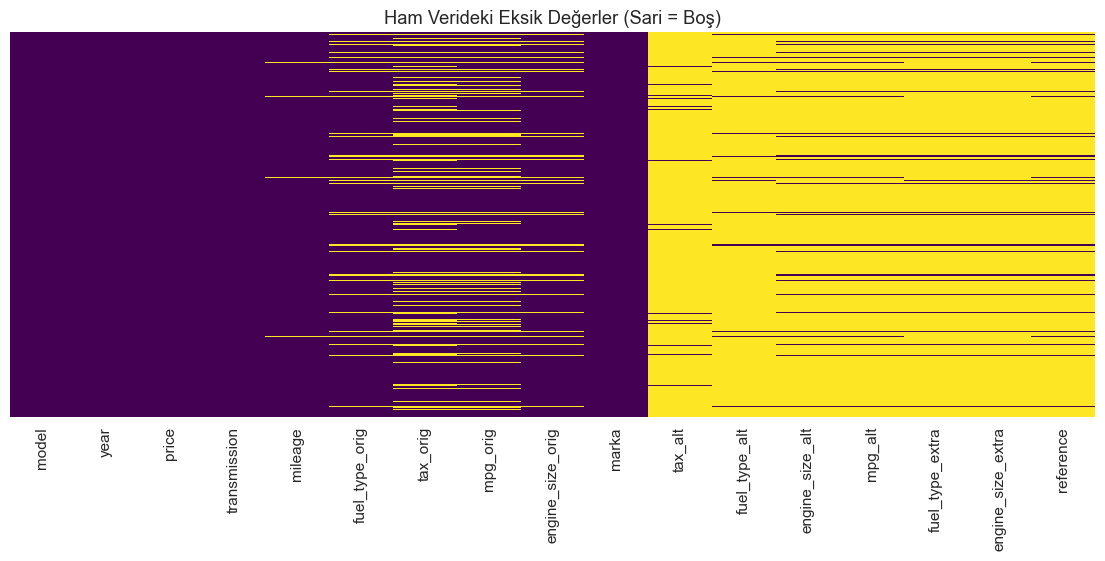

In [5]:
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Ham Verideki Eksik Değerler (Sari = Boş)')
plt.show()

## 2. Temel Temizlik Fonksiyonları
Sayısal verileri (Fiyat, Kilometre) temizlemek için regex kullanıyoruz.

In [6]:
def clean_num(x):
    if pd.isna(x): return x
    if isinstance(x, (int, float)): return float(x)
    cleaned = re.sub(r'[^\d.]', '', str(x))
    return float(cleaned) if cleaned else np.nan

def fix_engine(x):
    v = clean_num(x)
    if pd.isna(v): return v
    # 10 litreden büyük motor olmaz, muhtemelen CC cinsindendir (örn: 1600 -> 1.6)
    return v / 1000.0 if v > 10 else v

# Ana sütunlara uyguladık
df['price'] = df['price'].apply(clean_num)
df['mileage'] = df['mileage'].apply(clean_num)

## 3. Kaymış Verileri (Shifted Data) Tespit Etme
Bazı satırlarda verilerin sağa kaydığını fark ettik. Özellikle engine_size_alt sütununda Sterlin (£) işareti varsa, orada bir kayma var demektir.

In [7]:
mask_shifted = df['engine_size_alt'].astype(str).str.contains('£', na=False)
shifted_count = mask_shifted.sum()
normal_count = len(df) - shifted_count

print(f"-> Tespit edilen hatali (kaymis) satir sayisi: {shifted_count}")

-> Tespit edilen hatali (kaymis) satir sayisi: 2184


### Görselleştirme 2: Veri Kayması Oranı
Veri setinin ne kadarı hatalı formatta? Bunu bir pasta grafiği ile görelim.

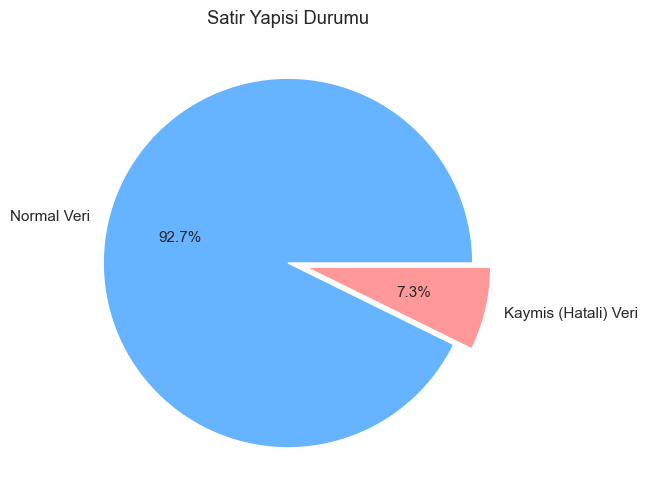

In [8]:
plt.figure(figsize=(6, 6))
plt.pie([normal_count, shifted_count], labels=['Normal Veri', 'Kaymis (Hatali) Veri'], 
        autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], explode=(0, 0.1))
plt.title('Satir Yapisi Durumu')
plt.show()

## 4. Kaymaları ve Boşlukları Düzeltme
Kaymış satırları doğru sütunlardan çekerek `f_` (fixed) ön ekiyle yeni sütunlara kaydediyoruz.

In [9]:
# Geçici sütunları oluşturduk
df['f_tax'] = df['tax_orig']
df['f_mpg'] = df['mpg_orig']
df['f_engine'] = df['engine_size_orig']
df['f_fuel'] = df['fuel_type_orig']

# Kaymış satırları doğru yerlerine oturtuyoruz
df.loc[mask_shifted, 'f_tax'] = df.loc[mask_shifted, 'engine_size_alt'].apply(clean_num)
df.loc[mask_shifted, 'f_mpg'] = df.loc[mask_shifted, 'mpg_alt'].apply(clean_num)
df.loc[mask_shifted, 'f_engine'] = df.loc[mask_shifted, 'engine_size_extra'].apply(fix_engine)
df.loc[mask_shifted, 'f_fuel'] = df.loc[mask_shifted, 'fuel_type_extra']

# Kalan boşlukları alternatif sütunlardan dolduruyoruz
df['f_tax'] = df['f_tax'].fillna(df['tax_alt'].apply(clean_num))
df['f_fuel'] = df['f_fuel'].fillna(df['fuel_type_alt'])

# Yakıt tipi filtresi
valid_fuels = ['Diesel', 'Petrol', 'Hybrid', 'Other', 'Electric']
df['f_fuel'] = df['f_fuel'].apply(lambda x: x if x in valid_fuels else np.nan)

###  Görselleştirme 3: Yakıt Tipi Dağılımı (Temizlik Sonrası)
Yakıt tiplerini temizledikten sonra dağılıma bakalım. Hangi araç türü çoğunlukta?

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15740\2860047638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='f_fuel', data=df, order=df['f_fuel'].value_counts().index, palette='viridis')


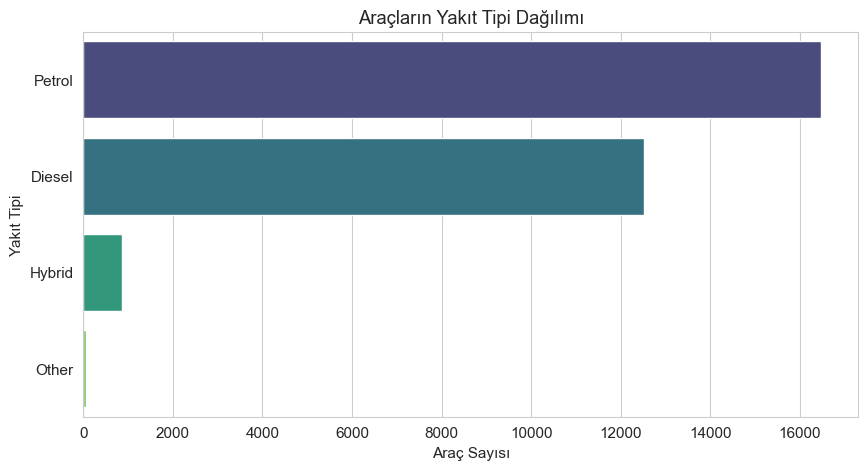

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(y='f_fuel', data=df, hue='f_fuel', order=df['f_fuel'].value_counts().index, palette='viridis', legend=False)
plt.title('Araçların Yakıt Tipi Dağılımı')
plt.xlabel('Araç Sayısı')
plt.ylabel('Yakıt Tipi')
plt.show()

## 5. Final Tablosunu Oluşturma
Artık temizlenmiş parçaları birleştirip `clean_df` oluşturabiliriz.

In [ ]:
clean_df = pd.DataFrame({
    'marka': df['marka'],
    'model': df['model'],
    'year': pd.to_numeric(df['year'], errors='coerce'),
    'transmission': df['transmission'],
    'mileage': df['mileage'].fillna(df['mpg_alt'].apply(clean_num)),
    'fuel_type': df['f_fuel'],
    'tax': df['f_tax'],
    'mpg': df['f_mpg'],
    'engine_size': df['f_engine'],
    'price': df['price']
})

# Araç Yaşı Ekleme
clean_df['car_age'] = 2025 - clean_df['year']

# Fiyatı olmayanları at
clean_df.dropna(subset=['price'], inplace=True)

print(f"-> Temiz Veri Hazır: {clean_df.shape}")
display(clean_df.head())

###  Görselleştirme 4: Fiyat ve Kilometre İlişkisi (Final Kontrol)
Veri mantıklı mı? Genellikle kilometre arttıkça fiyatın düşmesini bekleriz (Logaritmik azalış).

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clean_df, x='mileage', y='price', hue='fuel_type', alpha=0.4)
plt.title('Kilometre vs Fiyat (Yakıt Tipine Göre)')
plt.xlabel('Kilometre')
plt.ylabel('Fiyat (£)')
plt.show()

## 6. Kaydetme
Temiz veriyi modeller kullansın diye kaydediyorum.

In [ ]:
clean_df.to_csv('cleaned_data.csv', index=False)
print(" İşlem Tamamlandı: 'cleaned_data.csv' oluşturuldu.")